In [1]:
import eurostat
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

In [12]:
import eurostat
import pandas as pd
import os

def fetch_and_clean_eurostat(dataset_code, filter_params, col_name):
    df_raw = eurostat.get_data_df(dataset_code, filter_pars=filter_params)
    time_col = [col for col in df_raw.columns if 'TIME_PERIOD' in col][0]
    id_vars = df_raw.columns[:df_raw.columns.get_loc(time_col)+1].tolist()
    df_melted = df_raw.melt(id_vars=id_vars, var_name='date', value_name=col_name)
    df_melted['date'] = pd.to_datetime(df_melted['date'].str.replace('-M', '-'), format='%Y-%m')
    df_clean = df_melted[['date', col_name]].copy()
    df_clean[col_name] = pd.to_numeric(df_clean[col_name], errors='coerce')
    df_clean = df_clean[df_clean['date'] >= '2010-01-01']
    df_clean = df_clean.dropna()
    df_clean = df_clean.drop_duplicates(subset=['date'])
    return df_clean

# 1. Consumul de Energie
params_consum = {'geo': ['RO'], 'nrg_bal': ['AIM'], 'siec': ['E7000'], 'unit': ['GWH']}
df_consum = fetch_and_clean_eurostat('nrg_cb_em', params_consum, 'Consum_Energie_GWh')

# 2. Productia Industriala
params_industrie = {'geo': ['RO'], 'nace_r2': ['B-D'], 's_adj': ['NSA'], 'unit': ['I21']}
df_industrie = fetch_and_clean_eurostat('sts_inpr_m', params_industrie, 'Productie_Industriala_Idx')

# 3. Inflatie Energie (Sudura istoricului pe baza I15)
params_inflatie_old = {'geo': ['RO'], 'coicop': ['CP0451'], 'unit': ['I15']}
df_inflatie_old = fetch_and_clean_eurostat('prc_hicp_midx', params_inflatie_old, 'Inflatie_Energie_Ipc')

params_inflatie_new = {'geo': ['RO'], 'coicop18': ['CP04510'], 'unit': ['I15']}
df_inflatie_new = fetch_and_clean_eurostat('prc_hicp_minr', params_inflatie_new, 'Inflatie_Energie_Ipc')

df_inflatie = pd.concat([df_inflatie_old, df_inflatie_new])
df_inflatie = df_inflatie.drop_duplicates(subset=['date'], keep='last')

# Unificare Finala
df = pd.merge(df_consum, df_industrie, on='date', how='inner')
df = pd.merge(df, df_inflatie, on='date', how='inner')
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

# Salvare in folderul corect
output_path = os.path.join('..', 'data', 'baza_date_proiect.xlsx')
df.to_excel(output_path)

print("Shape final:", df.shape)
print("Interval date:", df.index.min().date(), "până la", df.index.max().date())
print("\nPrimele 5 înregistrări:")
df.head(5)

Shape final: (195, 3)
Interval date: 2010-01-01 până la 2026-03-01

Primele 5 înregistrări:


,Consum_Energie_GWh,Productie_Industriala_Idx,Inflatie_Energie_Ipc
date,,,
2010-01-01,4802.0,60.6,72.99
2010-02-01,4496.0,63.7,72.99
2010-03-01,4606.0,73.5,72.99
2010-04-01,4032.0,67.8,72.99
2010-05-01,3967.0,70.1,72.99


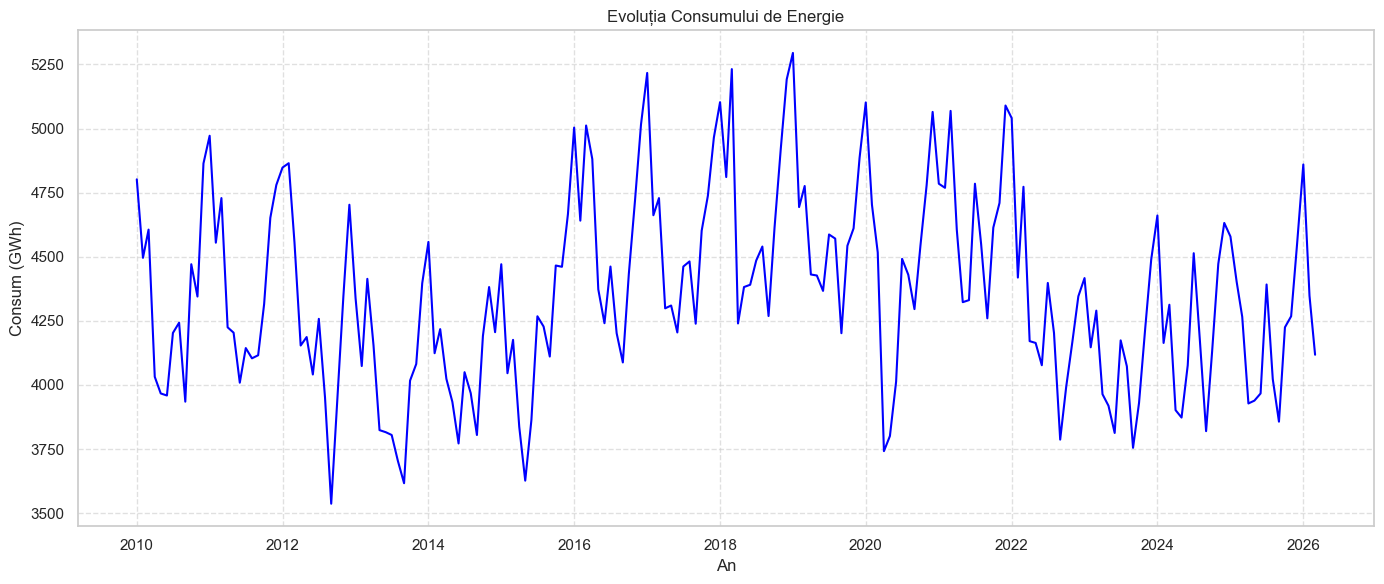

In [13]:
df.sort_index(inplace=True)

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Consum_Energie_GWh'], color='blue', linewidth=1.5)

plt.title('Evoluția Consumului de Energie')
plt.xlabel('An')
plt.ylabel('Consum (GWh)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [15]:
#Train-test split

train = df['Consum_Energie_GWh'][:-24]
test = df['Consum_Energie_GWh'][-24:]

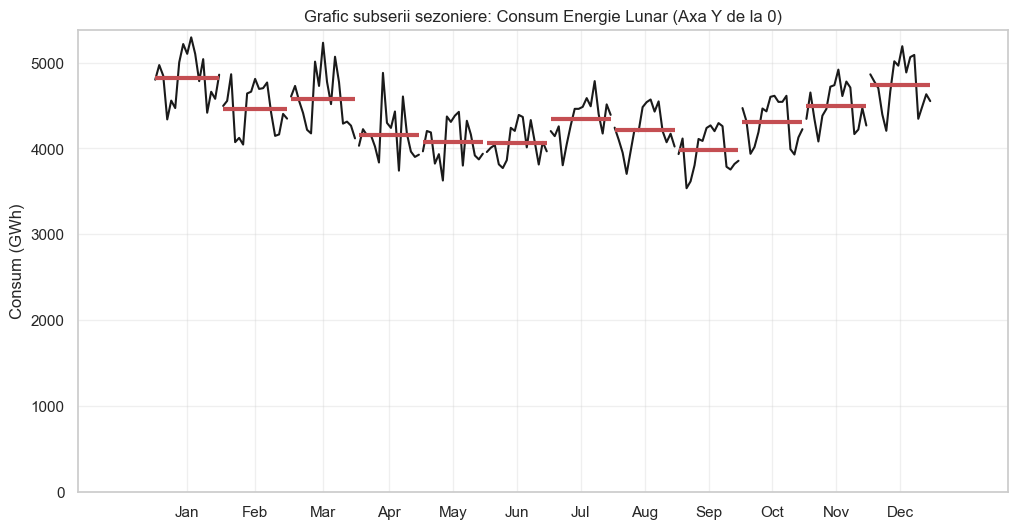

In [20]:
from statsmodels.graphics.tsaplots import month_plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
month_plot(df['Consum_Energie_GWh'].dropna(), ax=ax)

# Aici e magia: forțăm axa Y să înceapă de la 0
ax.set_ylim(bottom=0)

plt.title('Grafic subserii sezoniere: Consum Energie Lunar (Axa Y de la 0)')
plt.ylabel('Consum (GWh)')
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
import pmdarima as pm

# pmdarima rulează testul Canova-Hansen în spate și îți dă concluzia.
# Dacă rezultatul este 0 -> Sezonalitate stabilă (H0 acceptată)
# Dacă rezultatul este 1 -> Sezonalitate instabilă (H1 acceptată)

rezultat_ch = pm.arima.nsdiffs(df['Consum_Energie_GWh'].dropna(), m=12, test='ch')

print("--- Rezultat Test Canova-Hansen ---")
print(f"Valoarea returnată: {rezultat_ch}")

if rezultat_ch > 0:
    print("Concluzie: Tiparul sezonier este INSTABIL (respinge H0).")
else:
    print("Concluzie: Tiparul sezonier este STABIL (acceptă H0).")

--- Rezultat Test Canova-Hansen ---
Valoarea returnată: 0
Concluzie: Tiparul sezonier este STABIL (acceptă H0).


Rezultatele testului Canova-Hansen demonstreaza ca sezonalitatea prezenta in seria de consum energetic este una stabila. Deoarece ipoteza nula a fost acceptata, se poate concluziona ca tiparul sezonier nu necesita aplicarea unei diferentieri sezoniere pentru a asigura stationaritatea. Aceasta observatie sustine utilizarea seriei originale in procesul de modelare ulterioara, deoarece comportamentul sezonier al datelor se mentine constant si predictibil pe intreaga perioada analizata.

In [28]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

def check_stationarity(series, name):
    print(f"--- Teste de Stationaritate pentru {name} ---")

    # ADF Test
    adf_res = adfuller(series)
    print(f"ADF p-value: {adf_res[1]:.4f}")

    # KPSS Test
    kpss_res = kpss(series, regression='c', nlags="auto")
    print(f"KPSS p-value: {kpss_res[1]:.4f}")

    # Logica de decizie
    # ADF - vrem p < 0.05 pentru a respinge H0 (stationara)
    # KPSS (H0: seria este stationara) - vrem p > 0.05 pentru a accepta H0 (stationara)
    
    if adf_res[1] < 0.05 and kpss_res[1] > 0.05:
        print("Concluzie: Seria este probabil STATIONARA.\n")
    else:
        print("Concluzie: Seria este probabil NESTATIONARA (necesita diferentiere).\n")

# Aici folosim coloana ta specifica
check_stationarity(df['Consum_Energie_GWh'], "Consum Energie")

--- Teste de Stationaritate pentru Consum Energie ---
ADF p-value: 0.2492
KPSS p-value: 0.1000
Concluzie: Seria este probabil NESTATIONARA (necesita diferentiere).



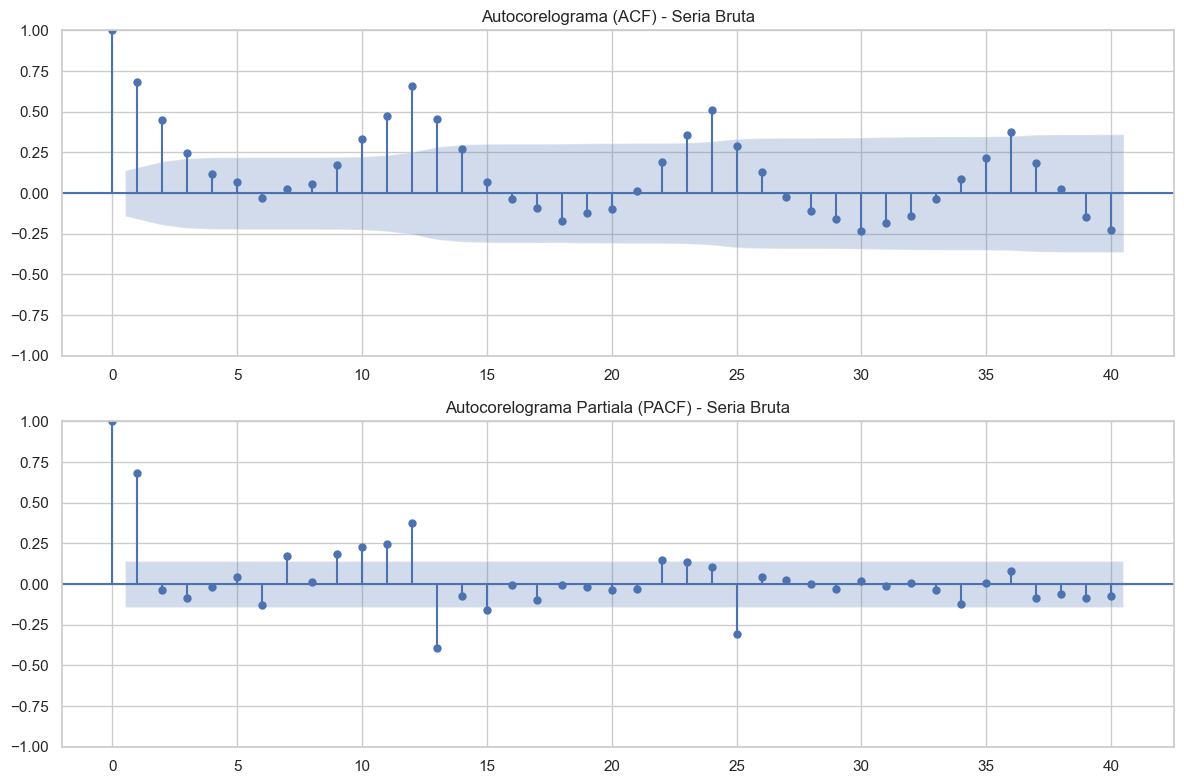

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
plot_acf(df['Consum_Energie_GWh'].dropna(), ax=axes[0], lags=40)
axes[0].set_title('Autocorelograma (ACF) - Seria Bruta')

# PACF
plot_pacf(df['Consum_Energie_GWh'].dropna(), ax=axes[1], lags=40, method='ywm')
axes[1].set_title('Autocorelograma Partiala (PACF) - Seria Bruta')

plt.tight_layout()
plt.show()

Corelograma ACF confirma prezenta unei sezonalitati anuale clare prin valorile semnificative la lag-urile 12, 24 si 36. Chiar daca testele de stabilitate sugereaza un tipar determinist, persistenta acestor corelatii justifica includerea parametrilor sezonieri in modelul SARIMA pentru a capta corect ciclicitatea consumului.

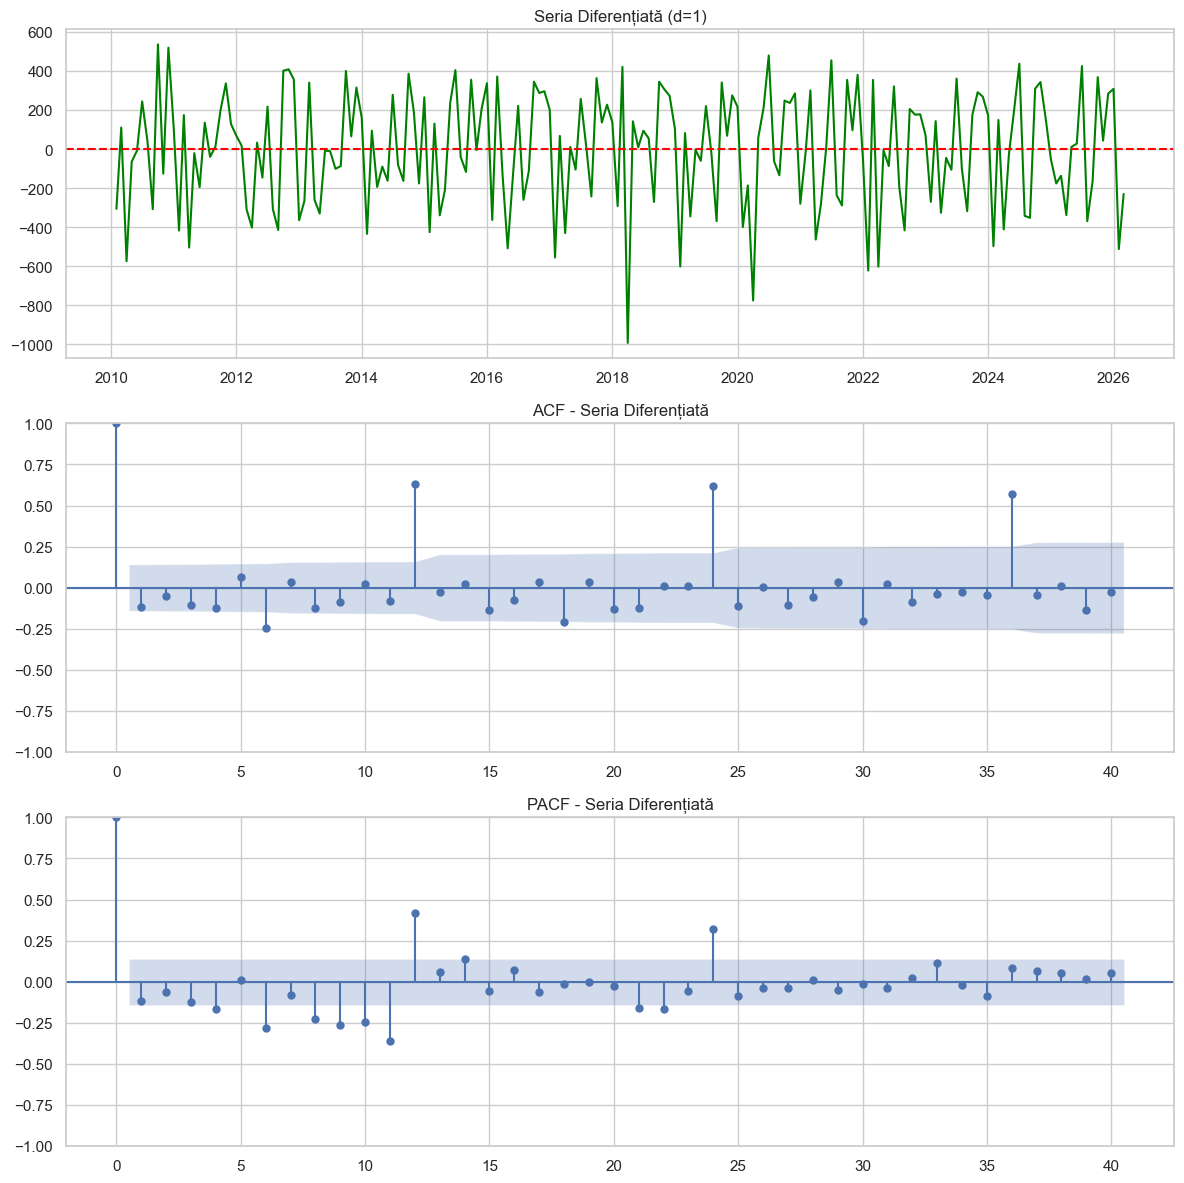

In [33]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Calculăm seria diferențiată (d=1)
# Eliminăm primul rând care devine NaN
df_diff = df['Consum_Energie_GWh'].diff().dropna()

# 2. Vizualizare: Seria diferențiată, ACF și PACF
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Plot Seria Diferențiată
axes[0].plot(df_diff, color='green')
axes[0].set_title('Seria Diferențiată (d=1)')
axes[0].axhline(0, color='red', linestyle='--') # Linia mediană

# Plot ACF
plot_acf(df_diff, ax=axes[1], lags=40)
axes[1].set_title('ACF - Seria Diferențiată')

# Plot PACF
plot_pacf(df_diff, ax=axes[2], lags=40, method='ywm')
axes[2].set_title('PACF - Seria Diferențiată')

plt.tight_layout()
plt.show()

SAR: 2

SMA: 3

AR: max 1

MA: max 1

In [37]:
import pmdarima as pm

model_sarima = pm.auto_arima(train, 
                      d=1,                # Diferențiere simplă
                      D=0,                
                      m=12,               # Frecvență lunară
                      
                      # Limite nesezoniere (AR maxim 1, MA maxim 1)
                      start_p=0, max_p=1,
                      start_q=0, max_q=1,
                      
                      # Limite sezoniere (SAR maxim 2, SMA maxim 3)
                      start_P=0, max_P=2,
                      start_Q=0, max_Q=3,
                      
                      seasonal=True,
                      trace=True,         # Vedem cum caută
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)

print(model_sarima.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2414.596, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2321.140, Time=0.17 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2365.264, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2412.613, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2413.028, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2289.411, Time=0.54 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.36 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=2294.397, Time=0.49 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=2284.764, Time=0.47 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=2317.970, Time=0.18 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=2257.598, Time=0.95 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : 

Modelul selectat este  SARIMA(0,1,1)(2,0,1)

Conform testului Ljung_Box nu am autocorelare in reziduuri.

Conform testului Jarque Bera teoretic nu am reziduuri normal distribuite, dar as putea spune ca am o distributia aproape normal distribuita, ea fiind usor leptokurtica.

Conform testului de heteroscedasticitate nu am reziduuri heteroscedastice, ele fiind homoscedastice, deci au varianta constanta.

--- Tabel Metrici Model ---
          Model Câștigător
MAE             226.271525
MAPE (%)          5.281349
MASE              0.946719
RMSE            256.894210
AIC            2257.598030
BIC            2276.412821


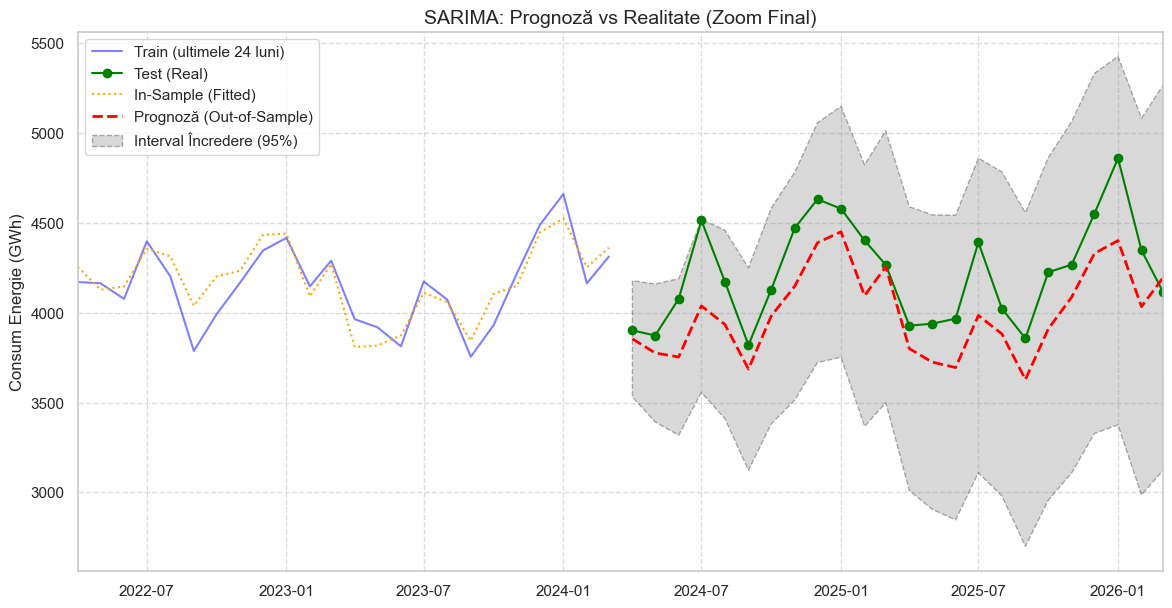

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Prognoză Out-of-sample (pe setul de test)
forecast_values, conf_int = model_sarima.predict(n_periods=len(test), return_conf_int=True)
forecast_series = pd.Series(forecast_values, index=test.index)
conf_int_df = pd.DataFrame(conf_int, index=test.index, columns=['lower', 'upper'])

# 2. Fitted values In-sample (pentru a vedea cum a învățat pe train)
in_sample_preds = model_sarima.predict_in_sample()
in_sample_series = pd.Series(in_sample_preds, index=train.index)

# 3. Calcul Metricilor
mae = mean_absolute_error(test, forecast_series)
rmse = np.sqrt(mean_squared_error(test, forecast_series))
mape = np.mean(np.abs((test - forecast_series) / test)) * 100

# MASE (Mean Absolute Scaled Error)
naive_mae_train = np.mean(np.abs(train.diff().dropna()))
mase = mae / naive_mae_train

metrics = {
    "MAE": mae,
    "MAPE (%)": mape,
    "MASE": mase,
    "RMSE": rmse,
    "AIC": model_sarima.aic(),
    "BIC": model_sarima.bic()
}

df_metrics = pd.DataFrame(metrics, index=["Model Câștigător"])
print("--- Tabel Metrici Model ---")
print(df_metrics.T)

# 4. Vizualizare cu Zoom și Stilizat
plt.figure(figsize=(14, 7))

# Plot train (doar ultimul segment de 24 luni pentru claritate)
# Ajustează indexul dacă train e prea scurt
zoom_start = train.index[-24] 
zoom_end = test.index[-1]

plt.plot(train.loc[zoom_start:].index, train.loc[zoom_start:], label='Train (ultimele 24 luni)', color='blue', alpha=0.5)
plt.plot(test.index, test, label='Test (Real)', color='green', marker='o', markersize=6)

# Plot in-sample (fitted) și out-of-sample (forecast)
plt.plot(in_sample_series.loc[zoom_start:].index, in_sample_series.loc[zoom_start:], label='In-Sample (Fitted)', color='orange', linestyle=':')
plt.plot(forecast_series.index, forecast_series, label='Prognoză (Out-of-Sample)', color='red', linestyle='--', linewidth=2)

# Plot interval de încredere stilizat (Gri cu margine)
plt.fill_between(conf_int_df.index, conf_int_df['lower'], conf_int_df['upper'], 
                 color='gray', alpha=0.3, label='Interval Încredere (95%)',
                 edgecolor='black', linestyle='--')

# Setări zoom și formatare
plt.xlim(zoom_start, zoom_end)
plt.title('SARIMA: Prognoză vs Realitate (Zoom Final)', fontsize=14)
plt.ylabel('Consum Energie (GWh)')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()

In [52]:
from statsmodels.stats.diagnostic import het_arch

# Aplicăm testul Engle (Lagrange Multiplier)
# Rezultatul confirmă (sau infirmă) dacă ai nevoie de GARCH
lm_stat, p_value, f_stat, f_p_value = het_arch(model_sarima.resid(), nlags=12)

print(f"Test Engle (LM Test pentru ARCH): p-value = {p_value:.4f}")

if p_value > 0.05:
    print("Concluzie pentru raport: Nu există efecte ARCH. Nu este necesar un model GARCH.")
else:
    print("Concluzie pentru raport: Există efecte ARCH! Aici ar trebui un model GARCH.")

Test Engle (LM Test pentru ARCH): p-value = 0.7388
Concluzie pentru raport: Nu există efecte ARCH. Nu este necesar un model GARCH.


--- Tabel Metrici Holt-Winters ---
          Holt-Winters (ETS)
MAE               197.035007
MAPE (%)            4.612506
MASE                0.824394
RMSE              229.501341
AIC              1747.261972
BIC              1797.528589


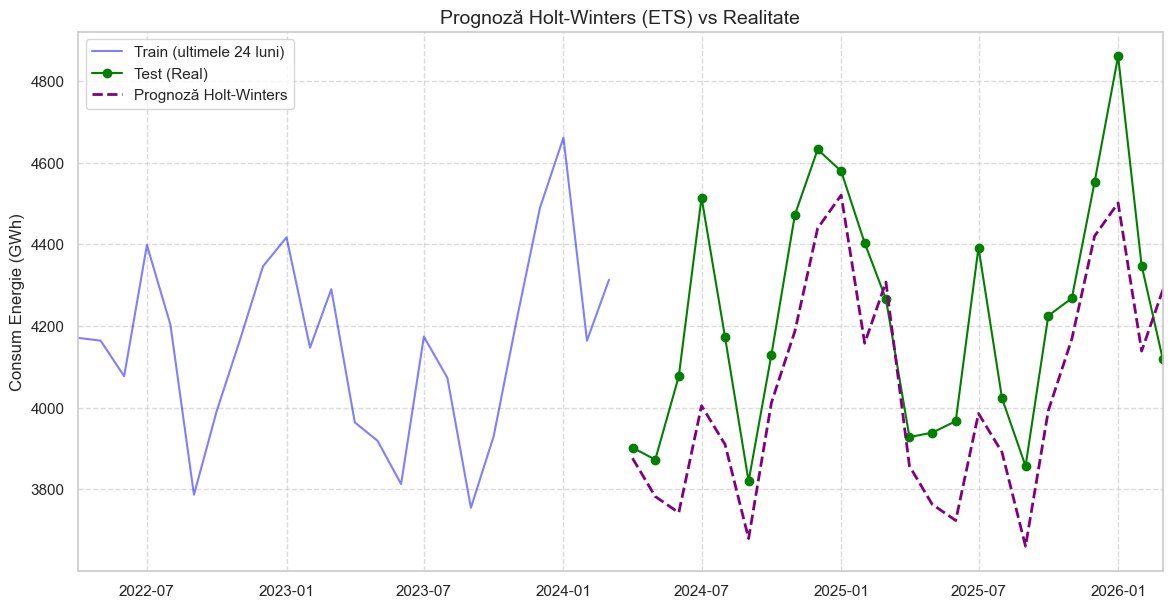

In [51]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Inițializare și Fit model Holt-Winters
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()

# 2. Prognoză pe setul de test
hw_forecast = hw_model.forecast(steps=len(test))
hw_forecast_series = pd.Series(hw_forecast, index=test.index)

# 3. Calcul Metricilor
mae_hw = mean_absolute_error(test, hw_forecast_series)
rmse_hw = np.sqrt(mean_squared_error(test, hw_forecast_series))
mape_hw = np.mean(np.abs((test - hw_forecast_series) / test)) * 100

# MASE
naive_mae_train = np.mean(np.abs(train.diff().dropna()))
mase_hw = mae_hw / naive_mae_train

# Adăugare AIC și BIC
metrics_hw = {
    "MAE": mae_hw,
    "MAPE (%)": mape_hw,
    "MASE": mase_hw,
    "RMSE": rmse_hw,
    "AIC": hw_model.aic,
    "BIC": hw_model.bic
}

df_metrics_hw = pd.DataFrame(metrics_hw, index=["Holt-Winters (ETS)"])
print("--- Tabel Metrici Holt-Winters ---")
print(df_metrics_hw.T)

# 4. Vizualizare (Zoom pe ultimele 24 luni + test)
zoom_start = train.index[-24] 
zoom_end = test.index[-1]

plt.figure(figsize=(14, 7))

plt.plot(train.loc[zoom_start:].index, train.loc[zoom_start:], label='Train (ultimele 24 luni)', color='blue', alpha=0.5)
plt.plot(test.index, test, label='Test (Real)', color='green', marker='o', markersize=6)
plt.plot(hw_forecast_series.index, hw_forecast_series, label='Prognoză Holt-Winters', color='purple', linestyle='--', linewidth=2)

# Setări grafic
plt.xlim(zoom_start, zoom_end)
plt.title('Prognoză Holt-Winters (ETS) vs Realitate', fontsize=14)
plt.ylabel('Consum Energie (GWh)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

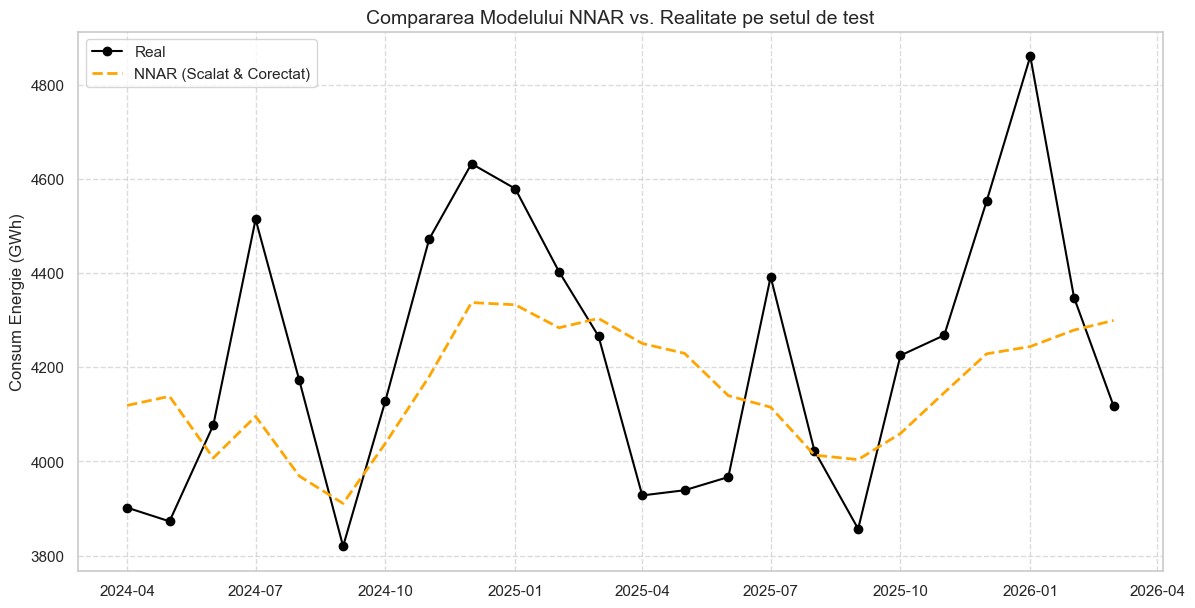

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# 0. INIȚIALIZARE ȘI SCALARE DATE
# ==========================================
# Inițializăm scaler-ul doar pe datele de TRAIN pentru a evita "data leakage"
scaler = MinMaxScaler(feature_range=(0, 1))

# Transformăm train și test în array-uri 2D pentru scaler
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test.values.reshape(-1, 1)).flatten()

# Convertim înapoi în Pandas Series pentru a păstra consistența scriptului tău
train_scaled_series = pd.Series(train_scaled, index=train.index)

# ==========================================
# 1. Pregătire date (creăm lag-uri din datele scalate)
# ==========================================
def create_lags(data, lags=12):
    df_lags = pd.concat([data.shift(i) for i in range(1, lags + 1)], axis=1)
    df_lags.columns = [f'lag_{i}' for i in range(1, lags + 1)]
    return df_lags.dropna(), data.iloc[lags:]

# Rulăm funcția pe seria scalată!
X_train, y_train = create_lags(train_scaled_series, lags=12)

# ==========================================
# 2. Model NNAR (MLP)
# ==========================================
nnar_model = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=2000, random_state=42)
nnar_model.fit(X_train, y_train)

# ==========================================
# 3. Prognoză recursivă (Totul se întâmplă SCALAT)
# ==========================================
# Plecăm de la ultimele 12 valori din TRAIN SCALAT
input_seq = train_scaled[-12:].tolist()
nnar_forecast_scaled = []

for _ in range(len(test)):
    # Predicția generată va fi o valoare între 0 și 1
    pred = nnar_model.predict(np.array(input_seq[-12:]).reshape(1, -1))[0]
    nnar_forecast_scaled.append(pred)
    input_seq.append(pred) # Adăugăm valoarea scalată în istoric pentru pasul următor

# Transformăm predicțiile scalate înapoi în unitatea originală (GWh) 
nnar_forecast_rescaled = scaler.inverse_transform(np.array(nnar_forecast_scaled).reshape(-1, 1)).flatten()
nnar_forecast_series = pd.Series(nnar_forecast_rescaled, index=test.index)

# ==========================================
# 4. Metricile pentru NNAR (calculate pe valorile reale, în GWh)
# ==========================================
mae_nnar = mean_absolute_error(test, nnar_forecast_series)
rmse_nnar = np.sqrt(mean_squared_error(test, nnar_forecast_series))
mape_nnar = np.mean(np.abs((test - nnar_forecast_series) / test)) * 100
mase_nnar = mae_nnar / naive_mae_train # naive_mae_train definit anterior

# ==========================================
# 5. Vizualizare Comparativă (Doar Real vs NNAR)
# ==========================================
plt.figure(figsize=(14, 7))

plt.plot(test.index, test, label='Real', color='black', marker='o')
plt.plot(test.index, nnar_forecast_series, label='NNAR (Scalat & Corectat)', color='orange', linestyle='--', linewidth=2)

plt.title('Compararea Modelului NNAR vs. Realitate pe setul de test', fontsize=14)
plt.ylabel('Consum Energie (GWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
# restul scriptului ramane neatins


--- TABEL COMPARATIV FINAL: Acuratețe Modele ---
                           MAE  MAPE (%)      MASE        RMSE
SARIMA              226.271525  5.281349  0.946719  256.894210
Holt-Winters (ETS)  197.035007  4.612506  0.824394  229.501341
NNAR (MLP)          209.997862  4.895832  0.878631  248.626528


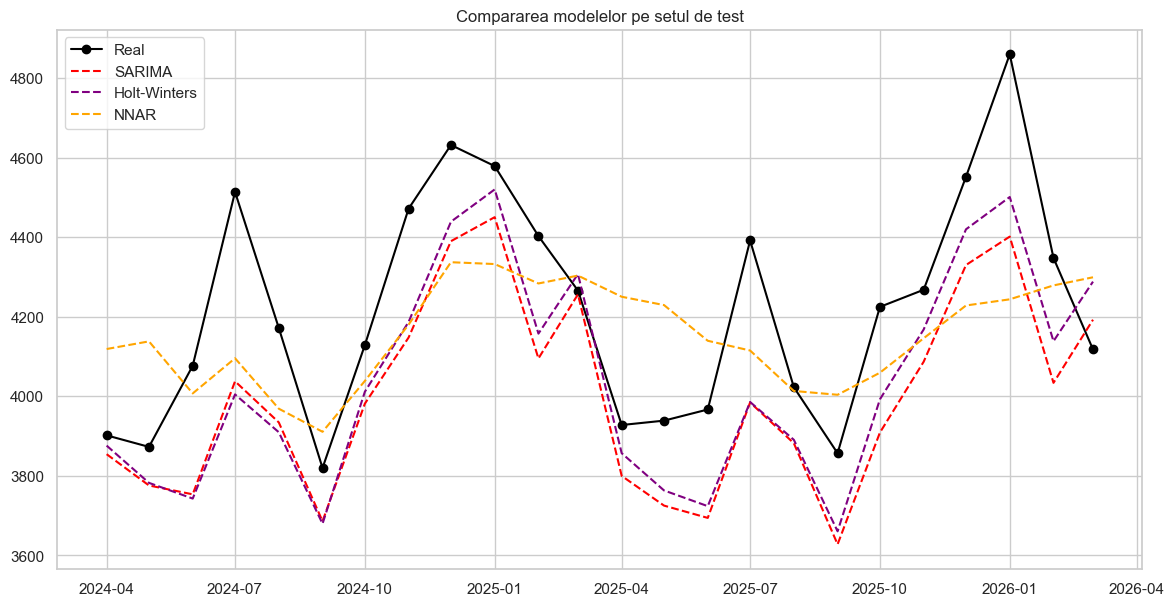

In [62]:
# 5. Tabel Comparativ Final
# (Aici introducem valorile colectate anterior pentru SARIMA și ETS)
final_comparison = pd.DataFrame({
    "SARIMA": [mae, mape, mase, rmse],
    "Holt-Winters (ETS)": [mae_hw, mape_hw, mase_hw, rmse_hw],
    "NNAR (MLP)": [mae_nnar, mape_nnar, mase_nnar, rmse_nnar]
}, index=["MAE", "MAPE (%)", "MASE", "RMSE"])

print("--- TABEL COMPARATIV FINAL: Acuratețe Modele ---")
print(final_comparison.T)

# 5. Vizualizare Comparativă (Zoom)
plt.figure(figsize=(14, 7))
plt.plot(test.index, test, label='Real', color='black', marker='o')
plt.plot(test.index, forecast_series, label='SARIMA', color='red', linestyle='--')
plt.plot(test.index, hw_forecast_series, label='Holt-Winters', color='purple', linestyle='--')
plt.plot(test.index, nnar_forecast_series, label='NNAR', color='orange', linestyle='--')

plt.title('Compararea modelelor pe setul de test')
plt.legend()
plt.grid(True)
plt.show()

Cel mai bun model conform metricilor MAE,MAPE,MASE si RMSE, unde luam cele mai mici valori, este netezirea exponentiala (H-W).

## Analiza multivariata

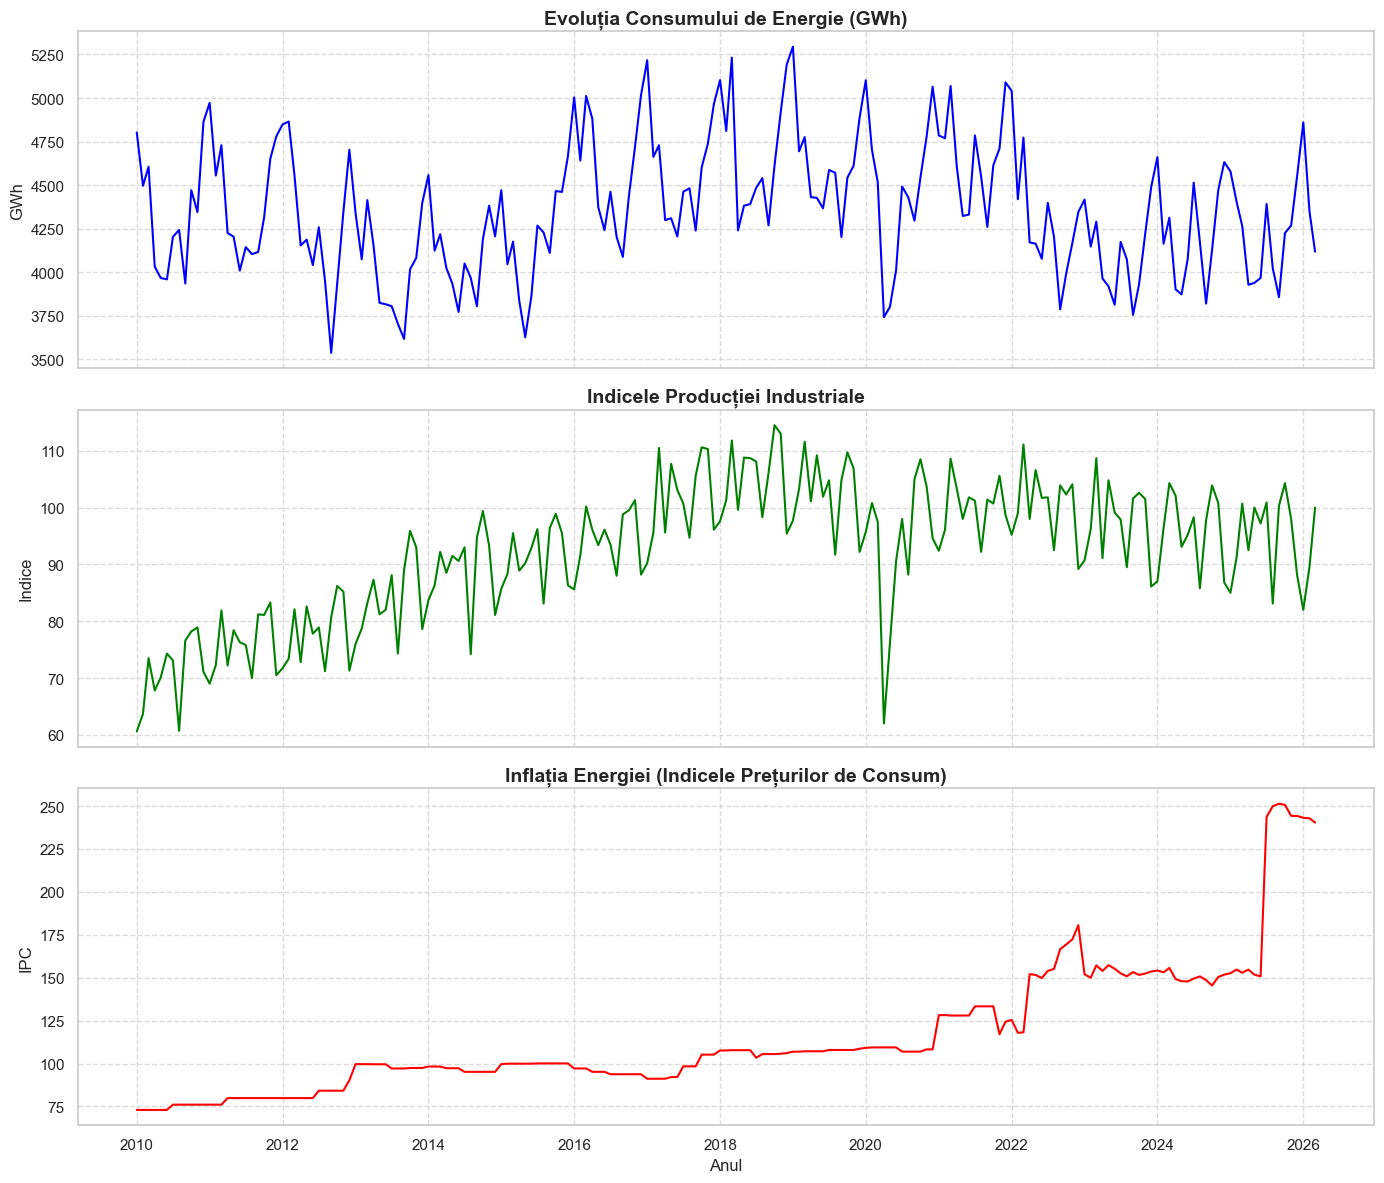

In [78]:
import matplotlib.pyplot as plt
import pandas as pd

# Presupunem că dataframe-ul tău se numește 'df'
# Asigură-te că data este setată ca index de tip datetime dacă nu este deja:
# df['date'] = pd.to_datetime(df['date'])
# df.set_index('date', inplace=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Consum de Energie (Seria Ta Principală)
axes[0].plot(df.index, df['Consum_Energie_GWh'], color='blue', linewidth=1.5)
axes[0].set_title('Evoluția Consumului de Energie (GWh)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('GWh')
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Producția Industrială
axes[1].plot(df.index, df['Productie_Industriala_Idx'], color='green', linewidth=1.5)
axes[1].set_title('Indicele Producției Industriale', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Indice')
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. Inflația Energiei (Prețul)
axes[2].plot(df.index, df['Inflatie_Energie_Ipc'], color='red', linewidth=1.5)
axes[2].set_title('Inflația Energiei (Indicele Prețurilor de Consum)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('IPC')
axes[2].grid(True, linestyle='--', alpha=0.7)

# Setări generale
plt.xlabel('Anul', fontsize=12)
plt.tight_layout() # Așează graficele frumos, fără să se suprapună
plt.show()

Analiza celor trei indicatori macroeconomici pentru România reflectă impactul direct al crizelor recente asupra economiei naționale. Consumul de energie și producția industrială au o sezonalitate pronunțată și marchează o contracție severă în 2020 generată de restricțiile pandemice. După un deceniu de stabilitate, inflația pe segmentul energetic a explodat în 2021-2022 pe fondul crizei europene și a liberalizării pieței interne, înregistrând un nou șoc extrem în 2025. Această scumpire masivă a energiei a oprit avansul producției industriale post-pandemie și a generat o tendință generală de scădere a consumului național.

In [79]:
import numpy as np
import pandas as pd

# Creăm un dataframe nou care va prelua indexul de timp (data) din df-ul vechi
df_log = pd.DataFrame(index=df.index)

# Aplicăm logaritmul natural și creăm noile coloane
df_log['Consum_log'] = np.log(df['Consum_Energie_GWh'])
df_log['Productie_log'] = np.log(df['Productie_Industriala_Idx'])
df_log['Inflatie_log'] = np.log(df['Inflatie_Energie_Ipc'])

# Afișăm primele 5 rânduri ca să ne asigurăm că transformarea a reușit
df_log.head()

,Consum_log,Productie_log,Inflatie_log
date,,,
2010-01-01,8.476788,4.104295,4.290322
2010-02-01,8.410943,4.154185,4.290322
2010-03-01,8.435115,4.297285,4.290322
2010-04-01,8.302018,4.216562,4.290322
2010-05-01,8.285765,4.249923,4.290322


In [80]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

def test_stationarity_log(series, title=''):
    print(f"=== {title} ===")
    
    # Test ADF
    adf_pvalue = adfuller(series.dropna(), autolag='AIC')[1]
    print(f"ADF p-value:  {adf_pvalue:.4f} -> {'Staționară (Respingem H0)' if adf_pvalue <= 0.05 else 'Non-staționară (Acceptăm H0)'}")

    # Test KPSS
    kpss_pvalue = kpss(series.dropna(), regression='c', nlags="auto")[1]
    print(f"KPSS p-value: {kpss_pvalue:.4f} -> {'Non-staționară (Respingem H0)' if kpss_pvalue <= 0.05 else 'Staționară (Acceptăm H0)'}")
    print("-" * 40)

# Rulăm pe coloanele logaritmate
for col in ['Consum_log', 'Productie_log', 'Inflatie_log']:
    test_stationarity_log(df_log[col], title=col)

=== Consum_log ===
ADF p-value:  0.2556 -> Non-staționară (Acceptăm H0)
KPSS p-value: 0.1000 -> Staționară (Acceptăm H0)
----------------------------------------
=== Productie_log ===
ADF p-value:  0.1459 -> Non-staționară (Acceptăm H0)
KPSS p-value: 0.0100 -> Non-staționară (Respingem H0)
----------------------------------------
=== Inflatie_log ===
ADF p-value:  0.9558 -> Non-staționară (Acceptăm H0)
KPSS p-value: 0.0100 -> Non-staționară (Respingem H0)
----------------------------------------


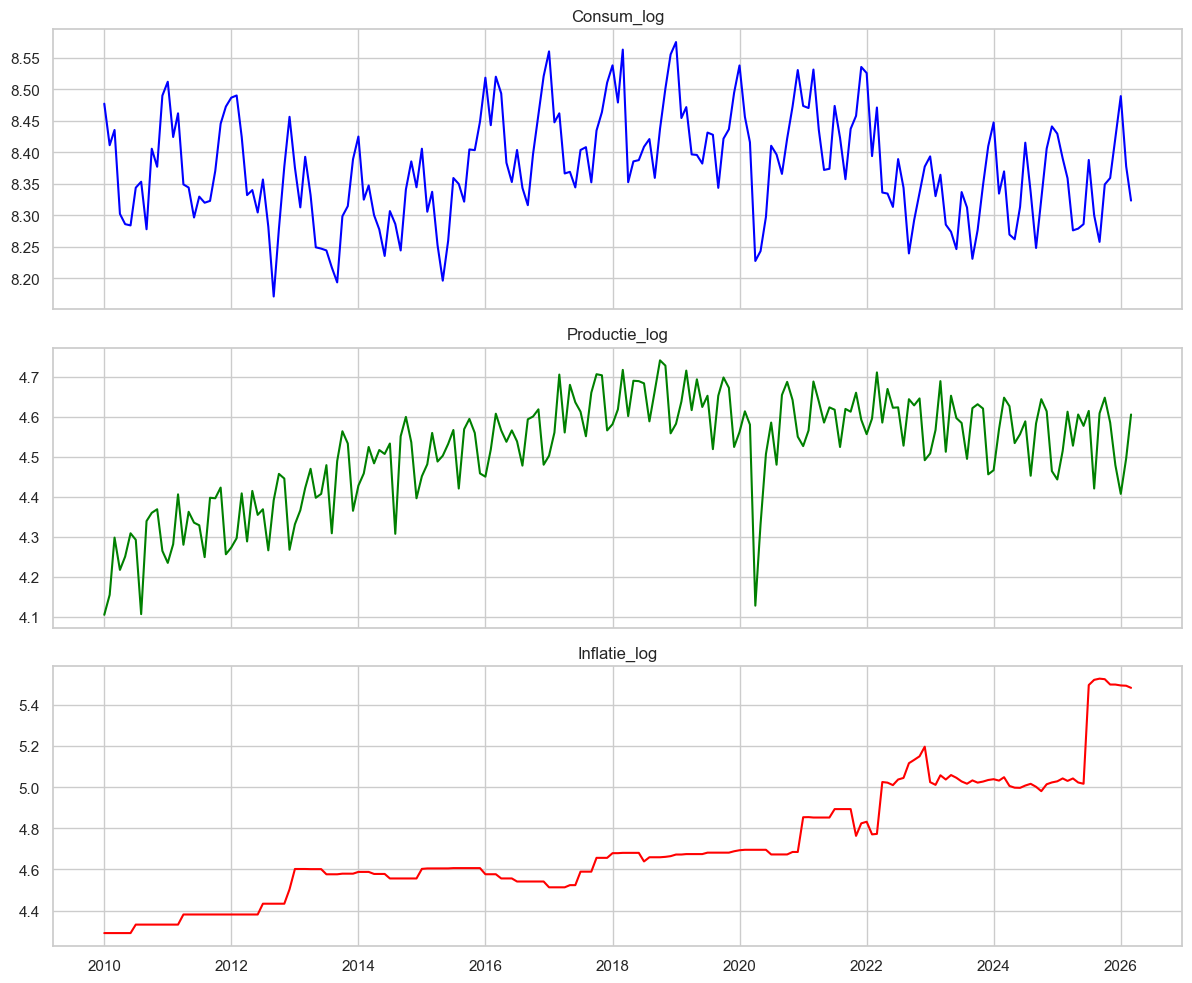

In [89]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df_log['Consum_log'], color='blue')
axes[0].set_title('Consum_log')

axes[1].plot(df_log['Productie_log'], color='green')
axes[1].set_title('Productie_log')

axes[2].plot(df_log['Inflatie_log'], color='red')
axes[2].set_title('Inflatie_log')

plt.tight_layout()
plt.show()

In [81]:
# Creăm un dataframe nou cu prima diferență a seriilor logaritmate
# dropna() este obligatoriu pentru că diferențierea pierde primul rând
df_log_diff = df_log.diff().dropna()

In [82]:
def test_stationarity_diff(series, title=''):
    print(f"=== {title} ===")
    
    # Test ADF (Vrem să respingem H0)
    adf_pvalue = adfuller(series, autolag='AIC')[1]
    print(f"ADF p-value:  {adf_pvalue:.4f} -> {'Staționară (Respingem H0)' if adf_pvalue <= 0.05 else 'Non-staționară (Acceptăm H0)'}")

    # Test KPSS (Vrem să acceptăm H0)
    kpss_pvalue = kpss(series, regression='c', nlags="auto")[1]
    print(f"KPSS p-value: {kpss_pvalue:.4f} -> {'Non-staționară (Respingem H0)' if kpss_pvalue <= 0.05 else 'Staționară (Acceptăm H0)'}")
    print("-" * 45)

# Rulăm testele pe seriile diferențiate
for col in ['Consum_log', 'Productie_log', 'Inflatie_log']:
    test_stationarity_diff(df_log_diff[col], title=col + " (Diferențiată)")

=== Consum_log (Diferențiată) ===
ADF p-value:  0.0023 -> Staționară (Respingem H0)
KPSS p-value: 0.1000 -> Staționară (Acceptăm H0)
---------------------------------------------
=== Productie_log (Diferențiată) ===
ADF p-value:  0.0000 -> Staționară (Respingem H0)
KPSS p-value: 0.1000 -> Staționară (Acceptăm H0)
---------------------------------------------
=== Inflatie_log (Diferențiată) ===
ADF p-value:  0.0000 -> Staționară (Respingem H0)
KPSS p-value: 0.1000 -> Staționară (Acceptăm H0)
---------------------------------------------


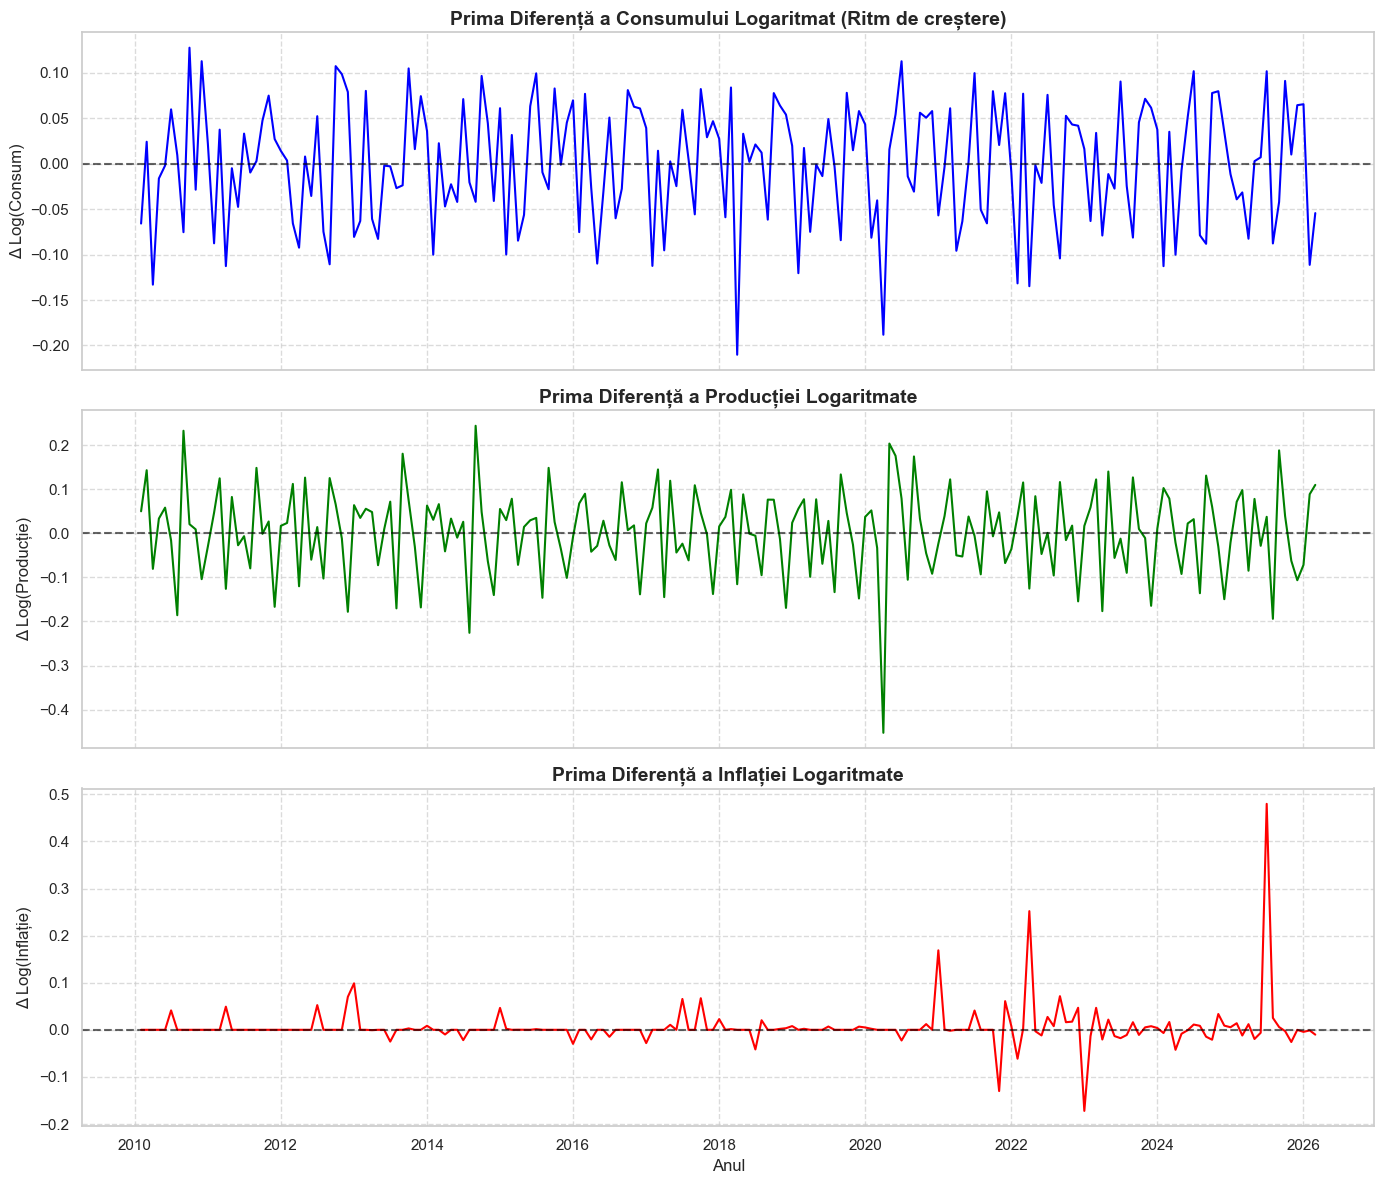

In [83]:
import matplotlib.pyplot as plt

# Creăm figura cu 3 grafice suprapuse
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Grafic Consum (Log Diferențiat)
axes[0].plot(df_log_diff.index, df_log_diff['Consum_log'], color='blue', linewidth=1.5)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.6) # Linia de 0
axes[0].set_title('Prima Diferență a Consumului Logaritmat (Ritm de creștere)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Δ Log(Consum)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Grafic Producție (Log Diferențiat)
axes[1].plot(df_log_diff.index, df_log_diff['Productie_log'], color='green', linewidth=1.5)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.6) # Linia de 0
axes[1].set_title('Prima Diferență a Producției Logaritmate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Δ Log(Producție)')
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. Grafic Inflație (Log Diferențiat)
axes[2].plot(df_log_diff.index, df_log_diff['Inflatie_log'], color='red', linewidth=1.5)
axes[2].axhline(0, color='black', linestyle='--', alpha=0.6) # Linia de 0
axes[2].set_title('Prima Diferență a Inflației Logaritmate', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Δ Log(Inflație)')
axes[2].grid(True, linestyle='--', alpha=0.7)

# Setări generale
plt.xlabel('Anul', fontsize=12)
plt.tight_layout()
plt.show()

In [84]:
import warnings
from statsmodels.tsa.api import VAR

warnings.filterwarnings("ignore")

# Selectăm variabilele din dataframe-ul logaritmat
df_model = df_log[['Consum_log', 'Productie_log', 'Inflatie_log']].dropna()

# Inițializăm un model VAR generic pentru a evalua lag-urile
model = VAR(df_model)

# Căutăm lag-ul optim testând până la 12 luni în urmă
lag_results = model.select_order(maxlags=12)

# Afișăm tabelul cu rezultate
print(lag_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -11.97      -11.92   6.306e-06      -11.95
1       -16.53      -16.32   6.632e-08      -16.44
2       -16.71     -16.34*   5.547e-08      -16.56
3       -16.66      -16.13   5.844e-08      -16.44
4       -16.94      -16.26   4.389e-08      -16.66
5       -16.93      -16.09   4.426e-08      -16.59
6       -17.01      -16.01   4.104e-08      -16.61
7       -17.00      -15.84   4.152e-08      -16.53
8       -17.10      -15.78   3.776e-08      -16.56
9       -17.21      -15.74   3.363e-08      -16.62
10      -17.26      -15.63   3.210e-08      -16.60
11      -17.46      -15.67   2.660e-08      -16.73
12     -17.62*      -15.68  2.258e-08*     -16.83*
--------------------------------------------------


Am ales lag-ul 2 indicat de criteriul BIC in locul lag-ului 12 sugerat de AIC pentru a pastra gradele de libertate. Un model cu 12 lag-uri aplicat pe 3 variabile necesita estimarea a peste 100 de parametri. Acest volum urias ar consuma prea multe grade de libertate in raport cu numarul de observatii disponibile din setul de date, ceea ce duce la supraparametrizare si la teste instabile. Prin urmare, alegerea lag-ului 2 asigura ca modelul isi pastreaza suficiente grade de libertate pentru a fi valid econometric.

In [102]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import pandas as pd

df_model = df_log[['Consum_log', 'Productie_log', 'Inflatie_log']].dropna()

johansen_test = coint_johansen(df_model, det_order=0, k_ar_diff=1)

rezultate = []
for i in range(len(johansen_test.lr1)):
    trace_stat = johansen_test.lr1[i]
    crit_90 = johansen_test.cvt[i, 0]
    crit_95 = johansen_test.cvt[i, 1]
    crit_99 = johansen_test.cvt[i, 2]
    
    if trace_stat > crit_95:
        verdict = "DA (Respingem H0)"
    else:
        verdict = "NU (Acceptam H0)"
        
    rezultate.append({
        'Ipoteza (H0)': f'r <= {i}',
        'Statistica Trace': round(trace_stat, 4),
        'Critic 90%': round(crit_90, 4),
        'Critic 95%': round(crit_95, 4),
        'Critic 99%': round(crit_99, 4),
        'Avem relatie?': verdict
    })

tabel_johansen = pd.DataFrame(rezultate)

print("=== Tabel Test Johansen (Statistica Trace) | Lag optim: 2 (k_ar_diff=1) ===")
print(tabel_johansen.to_string(index=False))

=== Tabel Test Johansen (Statistica Trace) | Lag optim: 2 (k_ar_diff=1) ===
Ipoteza (H0)  Statistica Trace  Critic 90%  Critic 95%  Critic 99%     Avem relatie?
      r <= 0           67.6927     27.0669     29.7961     35.4628 DA (Respingem H0)
      r <= 1           15.3215     13.4294     15.4943     19.9349  NU (Acceptam H0)
      r <= 2            0.0036      2.7055      3.8415      6.6349  NU (Acceptam H0)


La un prag de 95% avem posibila o relatie de cointegrare.

In [103]:
from statsmodels.tsa.vector_ar.vecm import VECM

df_model = df_log[['Consum_log', 'Productie_log', 'Inflatie_log']].dropna()

model_vecm = VECM(df_model, k_ar_diff=1, coint_rank=1, deterministic='co')
rezultat_vecm = model_vecm.fit()

print(rezultat_vecm.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation Consum_log
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.8156      0.300      6.047      0.000       1.227       2.404
L1.Consum_log       -0.0183      0.067     -0.273      0.785      -0.149       0.113
L1.Productie_log    -0.0440      0.049     -0.903      0.366      -0.139       0.051
L1.Inflatie_log     -0.1102      0.091     -1.207      0.228      -0.289       0.069
Det. terms outside the coint. relation & lagged endog. parameters for equation Productie_log
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.4530      0.405     -3.591      0.000      -2.246      -0.660
L1.Consum_log       -0.7163      0.090     -7.954   

Relatiile pe termen scurt ne arata cum se influenteaza variabilele de la o luna la alta. Conform rezultatelor modelului, evolutia consumului de energie din luna curenta nu este determinata de valorile din luna anterioara. In schimb, productia industriala curenta raspunde foarte puternic si direct la nivelul de consum inregistrat luna trecuta. Inflatia nu este influentata pe termen scurt de schimbarile consumului sau ale productiei, avand o evolutie independenta in acest sistem.

Consum_log = 0.6672 * Productie_log - 0.1725 * Inflatie_log

Aceasta ecuatie arata ca, pe termen lung, intre variabile exista o legatura stransa. O crestere a productiei industriale determina o crestere a consumului de energie. In schimb, inflatia are un efect invers, exercitand o presiune negativa care reduce consumul de energie pe termen lung. Ambele variabile au p-value egal cu 0.000, ceea ce inseamna ca influenta lor este certa si valida econometric.

In ecuatia pentru consum, coeficientul ec1 are valoarea de -0.2940 si este inalt semnificativ statistic, avand p-value 0.000. Semnul negativ indica faptul ca mecanismul de ajustare functioneaza corect. Mai exact, consumul absoarbe aproximativ 29.4% din orice dezechilibru intr-o singura luna. Astfel, sistemul are nevoie de aproximativ 3 pana la 4 luni pentru a reveni complet la starea de echilibru dupa aparitia unui soc.

In ecuatia pentru inflatie, coeficientul asociat termenului de corectie a erorii nu este semnificativ statistic, avand un p-value de 0.368. Acest rezultat ne arata ca inflatia actioneaza ca o variabila exogena in sistem. Ea nu se adapteaza pentru a corecta dezechilibrele aparute intre consum si productie, ci isi continua propria dinamica, fiind influentata cel mai probabil de alti factori externi macroeconomici.

În ecuația producției, coeficientul ec1 este pozitiv (0.2359). Acest lucru înseamnă că producția industrială este prea rigidă pe termen scurt pentru a repara dezechilibrele din piață. Prin urmare, ea nu ajută deloc la restabilirea echilibrului, lăsând toată povara ajustării exclusiv pe consum.

In [104]:
# 1. Testul de autocorelare a reziduurilor (Portmanteau)
test_autocorelare = rezultat_vecm.test_whiteness(nlags=5)
print("=== Testul de Autocorelare a Erorilor ===")
print(test_autocorelare.summary())
print("\n")

# 2. Testul de normalitate a reziduurilor (Jarque-Bera)
test_normalitate = rezultat_vecm.test_normality()
print("=== Testul de Normalitate a Erorilor ===")
print(test_normalitate.summary())

=== Testul de Autocorelare a Erorilor ===
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 5 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         104.4          47.40   0.000 33
----------------------------------------


=== Testul de Normalitate a Erorilor ===
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     2.517e+04          12.59   0.000  6
----------------------------------------


In [106]:
from statsmodels.tsa.vector_ar.var_model import VAR
import pandas as pd

# 1. Diferențiem datele
df_diff = df_log.diff().dropna()

# 2. Găsim lag-ul optim
model_selector = VAR(df_diff)
lag_selection = model_selector.select_order(maxlags=12)
print("--- Alegere lag optim ---")
print(lag_selection.summary())

# 3. Estimăm modelul (înlocuiește numărul de mai jos cu lag-ul indicat de tabelul de sus, ex: 1, 2, 3)
# Uită-te după steluța (*) în tabelul de mai sus pentru a alege lag-ul corect
lag_ales = 2 
model_var = model_selector.fit(lag_ales) 
print("\n--- Rezultate model VAR ---")
print(model_var.summary())

# 4. Verificăm autocorelarea (Testul de Whiteness)
print("\n--- Test autocorelare (Whiteness) ---")
print(model_var.test_whiteness(nlags=10).summary())

--- Alegere lag optim ---
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -16.14      -16.09   9.751e-08      -16.12
1       -16.41      -16.20   7.436e-08      -16.33
2       -16.42      -16.05   7.381e-08      -16.27
3       -16.73     -16.20*   5.416e-08      -16.52
4       -16.82      -16.13   4.956e-08      -16.54
5       -16.86      -16.01   4.782e-08      -16.51
6       -16.92      -15.92   4.480e-08      -16.52
7       -16.97      -15.81   4.290e-08      -16.50
8       -17.17      -15.85   3.503e-08      -16.64
9       -17.26      -15.78   3.224e-08      -16.66
10      -17.45      -15.81   2.672e-08      -16.78
11      -17.60      -15.81   2.300e-08     -16.87*
12     -17.63*      -15.67  2.249e-08*      -16.84
--------------------------------------------------

--- Rezultate model VAR ---
  Summary of Regression Results   
Model:                         VAR
Method: 